# Netflix Churn

In [ ]:
# HACER CORRER PRIMERO PARA IMPORTAR LAS LIBRERIAS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [ ]:
# 1. cargando el dataset desde github
url = "https://raw.githubusercontent.com/MarioVelasco00/netflix-churn-prediction/refs/heads/main/netflix_churn.csv"
df = pd.read_csv(url)
display(df.head())

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


Precision del modelo entrenado: 90.60%


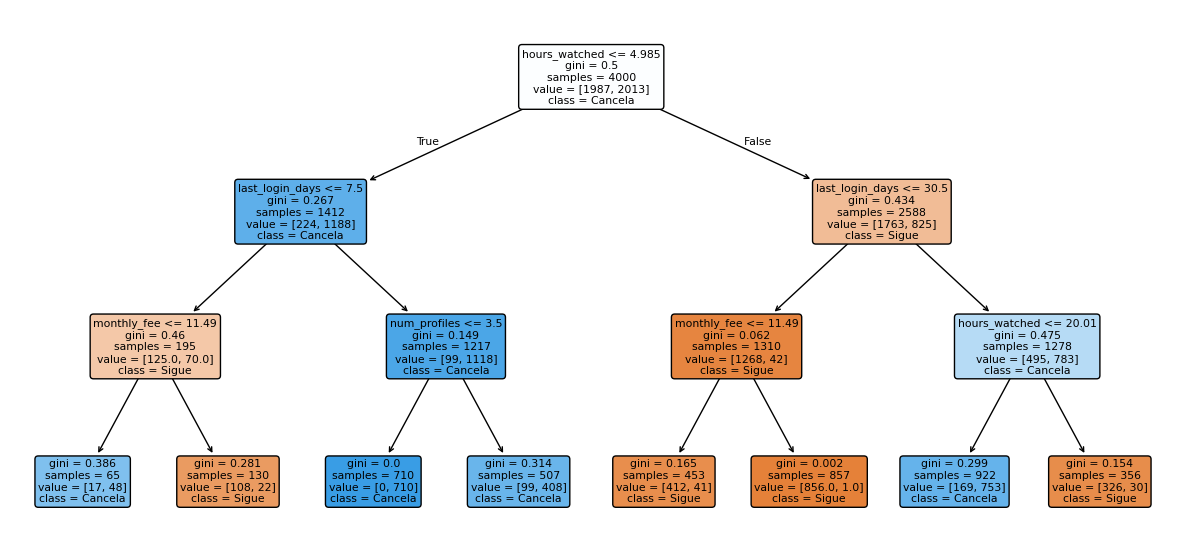

In [ ]:
# 2. renombrando columnas
df = df.rename(columns={
    'watch_hours': 'hours_watched',
    'number_of_profiles': 'num_profiles'
})

# convertir regiones a números
regiones = df['region'].unique()
mapa_regiones = {region: i+1 for i, region in enumerate(regiones)}
df['region_code'] = df['region'].map(mapa_regiones)


# 3. separar las variables de entrada y la salida
columnas_uso = ['monthly_fee', 'last_login_days', 'hours_watched', 'age', 'num_profiles', 'region_code']
X = df[columnas_uso]
y = df['churned']

# dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. entrenar el arbol con una profundidad de 3 niveles
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

# calcular y mostrar la precisión del modelo
precision = modelo.score(X_test, y_test)
print(f"Precision del modelo entrenado: {precision * 100:.2f}%")

# 5. dibujar el árbol para la presentación
plt.figure(figsize=(15, 7))
plot_tree(modelo, feature_names=columnas_uso, class_names=['Sigue', 'Cancela'], filled=True, rounded=True)
plt.show()

In [ ]:
#@title Sistema de Inferencia Interactiva - Netflix Churn
#@markdown Selecciona las características del cliente y presiona Play para predecir.

tarifa_mensual = 8 #@param {type:"slider", min:5.0, max:20.0, step:1.0}
dias_inactivo = 9 #@param {type:"slider", min:0, max:60, step:1}
horas_vistas = 13 #@param {type:"slider", min:0, max:100, step:1}
edad = 53 #@param {type:"slider", min:18, max:70, step:1}
perfiles = 3 #@param {type:"slider", min:1, max:5, step:1}
region_seleccionada = "Europe" #@param ["Africa", "Europe", "Asia", "Oceania", "South America", "North America"]

# El código busca automáticamente qué número le toca a esa región según el mapa de la Celda 1
codigo_region = mapa_regiones[region_seleccionada]

# Convertir los datos al formato que el árbol entiende
cliente_interactivo = pd.DataFrame([{
    'monthly_fee': tarifa_mensual,
    'last_login_days': dias_inactivo,
    'hours_watched': horas_vistas,
    'age': edad,
    'num_profiles': perfiles,
    'region_code': codigo_region
}])

# Predicción
prediccion = modelo.predict(cliente_interactivo)

# Mostrar el resultado final en pantalla
print("--- DATOS CLIENTE ---")
print(f"Tarifa: ${tarifa_mensual} | Días Inactivo: {dias_inactivo} | Horas Vistas: {horas_vistas}")
print(f"Edad: {edad} | Perfiles: {perfiles} | Región: {region_seleccionada} (Código {codigo_region})")

print("\n--- RESULTADO DE PREDICCIÓN ---")
if prediccion[0] == 1:
    print("[ALTO RIESGO] -> El usuario probablemente cancelará su suscripción en la plataforma.")
else:
    print("[FIDELIZADO] -> El usuario probablemente se quedará activo en la plataforma.")

--- DATOS CLIENTE ---
Tarifa: $8 | Días Inactivo: 9 | Horas Vistas: 13
Edad: 53 | Perfiles: 3 | Región: Europe (Código 2)

--- RESULTADO DE PREDICCIÓN ---
[FIDELIZADO] -> El usuario probablemente se quedará activo en la plataforma.
